In [222]:
import pandas as pd

In [247]:
def get_team_df():
    teams=['East Bay Hackers',
            'CV Bombers',
            'Diamond In The Ruf',
            'Wonger Jr',
            'Team Stokes',
            'MJ 2.0',
            'The JROD Show',
            'Amateur 2.0',
            'Inglorious Batters',
            'Fred Lewis T-Shirt Jersey',
            'The Friendly Confines',
            'Dutch Destroyer']


    filename = 'draft_recap.csv'


    split_csv = {}
    with open(filename) as f:

        lines = f.readlines()

        for line in lines:

            for name in teams:

                if name in line:

                    cur_team = name
                    split_csv[cur_team] = ""
                    team_change = True

            if team_change:
                team_change = False
                continue

            if len(split_csv[cur_team]) == 0:
                edited_line = 'number,player,team,position,round\n'

            else:
                line = line.replace('"', '')

                split = line.split(',')
                info = split[1]
                pivot = len(info) - 3

                split[1] = info[:pivot].strip() + ',' + info[pivot : ].strip()
                split = [ val.strip() for val in split ]


                edited_line = ",".join(split) + "\n"

            split_csv[cur_team] += edited_line
            team_dfs = {}
    for team, data in split_csv.items():

        df = pd.read_csv(StringIO(data), sep=",")
        team_dfs[team] = df
    return team_dfs




In [248]:
import sys
if sys.version_info[0] < 3: 
    from StringIO import StringIO
else:
    from io import StringIO
    
team_dfs = {}
for team, data in split_csv.items():

    df = pd.read_csv(StringIO(data), sep=",")
    team_dfs[team] = df


In [249]:
team_df = get_team_df()

In [250]:
cols = ["Name", 'HR', 'RBI', 'SB', 'SO', 'OBP']

projections = pd.read_csv('projections.csv')
projections = projections[cols]
projections = projections.rename(columns={"Name": "player" , "SO": "Ks"})


In [251]:
for team, df in team_dfs.items():
    hitters = df[(df['position'] != 'RP') & (df['position'] != 'SP')]
    new_df = pd.merge(hitters, projections, on='player', how='inner')
    print(new_df)
    team_dfs[team] = new_df

    number             player team position  round    HR   RBI    SB     Ks  \
0        9     Bobby Witt Jr.   KC       SS      1  29.4  88.9  40.3  111.7   
1       16       Bryce Harper  Phi       1B      2  29.8  93.5  11.9  130.0   
2       33  Michael Harris II  Atl       CF      3  23.3  88.4  22.1  114.5   
3       57        Matt McLain  Cin       SS      5  23.4  75.1  18.7  154.6   
4      105    George Springer  Tor       RF      9  23.6  72.5  13.6  111.4   
5      129      Brandon Nimmo  NYM       CF     11  18.9  67.5   5.7  130.7   
6      160     Wyatt Langford  Tex       LF     14  24.4  77.4  19.6  118.5   
7      177       Mitch Garver  Sea        C     15  18.7  54.2   1.1  104.8   
8      184          Alec Bohm  Phi       3B     16  18.7  79.0   4.6  108.2   
9      201       Riley Greene  Det       CF     17  16.1  62.6   7.3  147.4   
10     208    Jackson Chourio  Mil       CF     18  16.9  61.6  33.1  118.4   
11     225      Carlos Correa  Min       SS     19  

In [252]:
stat_cols = ['HR', 'RBI', 'SB', 'Ks', 'OBP']
desc = {}

for team , df in team_dfs.items():
    desc[team] = df[stat_cols].describe().loc['mean'].to_dict()

In [253]:
desc['Dutch Destroyer']

{'HR': 22.786666666666672,
 'RBI': 73.11333333333332,
 'SB': 10.560000000000002,
 'Ks': 130.88666666666666,
 'OBP': 0.33426666666666666}

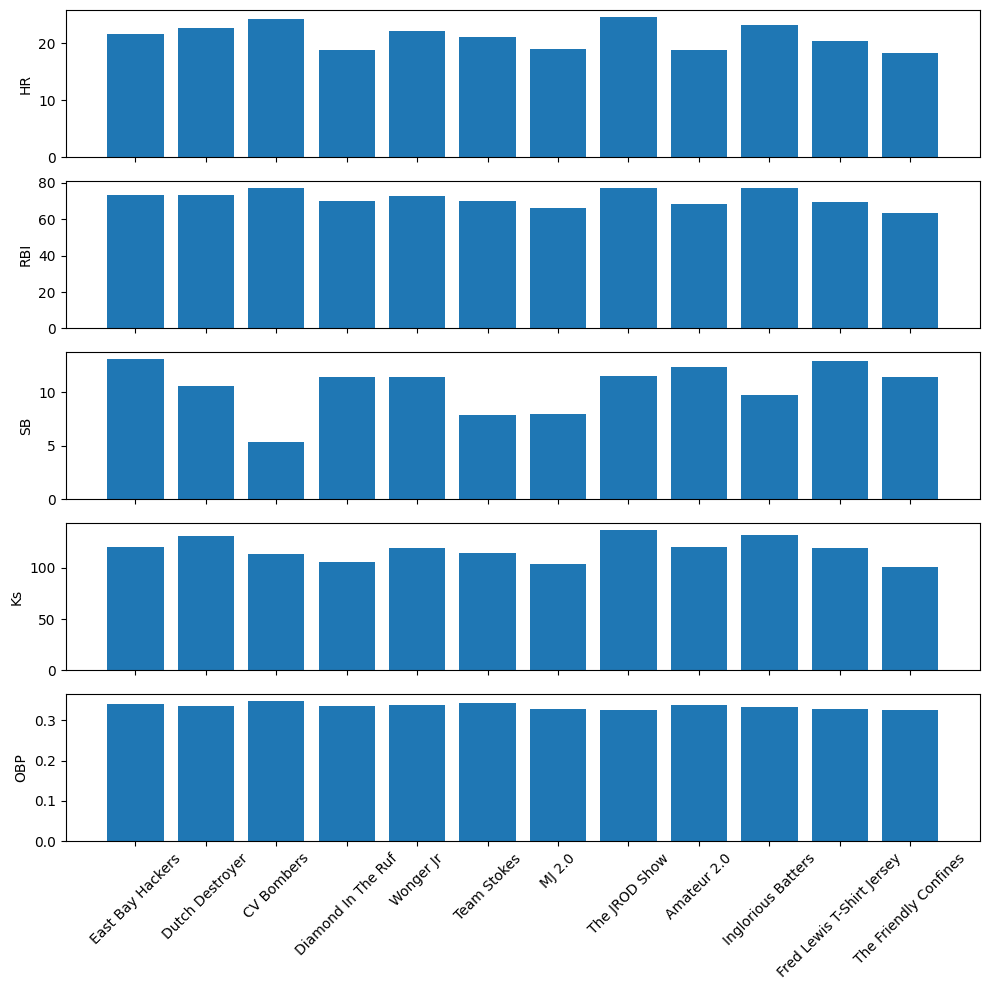

In [254]:
import matplotlib.pyplot as plt

columns = list(desc['East Bay Hackers'].keys())
mean_values = {team: list(values.values()) for team, values in desc.items()}

fig, axs = plt.subplots(len(columns), 1, figsize=(10, 10), sharex=True)

for i, column in enumerate(columns):
    axs[i].bar(desc.keys(), [values[i] for values in mean_values.values()])
    axs[i].set_ylabel(column)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [257]:
df = pd.DataFrame(desc)

df = df.transpose()
df['Ks'] = df['Ks'] * -1

ranked_df_hitters = df.rank(ascending=False).astype(int)

print("Ranking of each team for each category:")
print(ranked_df_hitters)

Ranking of each team for each category:
                           HR  RBI  SB  Ks  OBP
East Bay Hackers            6    4   1   8    3
Dutch Destroyer             4    5   8  10    7
CV Bombers                  2    2  12   4    1
Diamond In The Ruf         11    7   5   3    6
Wonger Jr                   5    6   6   7    5
Team Stokes                 7    8  11   5    2
MJ 2.0                      9   11  10   2   10
The JROD Show               1    1   4  12   11
Amateur 2.0                10   10   3   9    4
Inglorious Batters          3    3   9  11    8
Fred Lewis T-Shirt Jersey   8    9   2   6    9
The Friendly Confines      12   12   7   1   12


In [271]:

cols = ["Name" , "BB", "QS", "ERA", "SVHLD", "K"]
pitch = pd.read_csv('pitch.csv')
pitch["SVHLD"] = pitch['SV'] + pitch['HLD']
pitch = pitch[cols]
pitch = pitch.rename(columns={"Name": "player"})

In [272]:
team_dfs = get_team_df()
for team, df in team_dfs.items():
    pitchers = df[(df['position'] == 'RP') | (df['position'] == 'SP')]
    new_df = pd.merge(pitchers, pitch, on='player', how='inner')
    team_dfs[team] = new_df

stat_cols = ["BB", "QS", "ERA", "SVHLD", "K"]
desc = {}

for team , df in team_dfs.items():
    desc[team] = df[stat_cols].describe().loc['mean'].to_dict()
    
    
    
df = pd.DataFrame(desc)

df = df.transpose()
df['BB'] = df['BB'] * -1

ranked_df_pitch = df.rank(ascending=False).astype(int)

In [273]:

ranked_df = pd.concat([ranked_df_hitters, ranked_df_pitch], axis=1,join='inner')
print(ranked_df_hitters)
print(ranked_df_pitch)
print(ranked_df)

                           HR  RBI  SB  Ks  OBP
East Bay Hackers            6    4   1   8    3
Dutch Destroyer             4    5   8  10    7
CV Bombers                  2    2  12   4    1
Diamond In The Ruf         11    7   5   3    6
Wonger Jr                   5    6   6   7    5
Team Stokes                 7    8  11   5    2
MJ 2.0                      9   11  10   2   10
The JROD Show               1    1   4  12   11
Amateur 2.0                10   10   3   9    4
Inglorious Batters          3    3   9  11    8
Fred Lewis T-Shirt Jersey   8    9   2   6    9
The Friendly Confines      12   12   7   1   12
                           BB  QS  ERA  SVHLD   K
East Bay Hackers           12   4   10      9   3
Dutch Destroyer             8   6    4      3   7
CV Bombers                  1  12    5      7  12
Diamond In The Ruf          6   3    7     11   4
Wonger Jr                   9   1    1     12   2
Team Stokes                 7   7    2      5   5
MJ 2.0                    

In [274]:
ranked_df.mean(axis=1).sort_values()

Wonger Jr                    5.4
CV Bombers                   5.8
Team Stokes                  5.9
Fred Lewis T-Shirt Jersey    5.9
East Bay Hackers             6.0
Dutch Destroyer              6.2
Diamond In The Ruf           6.3
Amateur 2.0                  6.6
The JROD Show                6.9
The Friendly Confines        7.2
Inglorious Batters           7.6
MJ 2.0                       8.1
dtype: float64

In [277]:
print(ranked_df_hitters)

                           HR  RBI  SB  Ks  OBP
East Bay Hackers            6    4   1   8    3
Dutch Destroyer             4    5   8  10    7
CV Bombers                  2    2  12   4    1
Diamond In The Ruf         11    7   5   3    6
Wonger Jr                   5    6   6   7    5
Team Stokes                 7    8  11   5    2
MJ 2.0                      9   11  10   2   10
The JROD Show               1    1   4  12   11
Amateur 2.0                10   10   3   9    4
Inglorious Batters          3    3   9  11    8
Fred Lewis T-Shirt Jersey   8    9   2   6    9
The Friendly Confines      12   12   7   1   12


In [ ]:
'''
                           HR  RBI  SB  Ks  OBP
East Bay Hackers            6    4   1   8    3
Dutch Destroyer             4    5   8  10    7
CV Bombers                  2    2  12   4    1
Diamond In The Ruf         11    7   5   3    6
Wonger Jr                   5    6   6   7    5
Team Stokes                 7    8  11   5    2
MJ 2.0                      9   11  10   2   10
The JROD Show               1    1   4  12   11
Amateur 2.0                10   10   3   9    4
Inglorious Batters          3    3   9  11    8
Fred Lewis T-Shirt Jersey   8    9   2   6    9
The Friendly Confines      12   12   7   1   12
'''